## Auditoría y preparación del análisis

Este notebook carga el dataset, crea variables codificadas, calcula estadísticas descriptivas y visualiza la relación entre horas de pantalla y concentración sin celular.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
from pathlib import Path

# Carga segura del archivo base del análisis
DATA_PATH = Path("dataset_fusionado.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

### Carga de datos

Se valida la existencia del archivo antes de leerlo para evitar fallos silenciosos al ejecutar el notebook de forma secuencial.

In [3]:
categorical_columns = [
    "ocupacion",
    "app_mas_usada",
    "categoria_app_principal",
    "intento_reducir_pantalla",
    "origen",
]

missing_categorical = [column for column in categorical_columns if column not in df.columns]
if missing_categorical:
    raise KeyError(f"Faltan columnas categóricas requeridas: {missing_categorical}")

df_moded = pd.get_dummies(df.copy(), columns=categorical_columns)

### Codificación y limpieza

Se crean variables dummy para las columnas categóricas principales y luego se normalizan los campos ordinales para conservar el sentido de la escala original.

In [4]:
rango_edad_map = {
    '18-25': 2,
    '26-35': 3,
    'Menor de 17': 1,
    'Más de 35': 4,
}
horas_pantalla_map = {
    'Menos de 2 horas': 1,
    'Entre 2 a 4 horas': 2,
    'Entre 4 a 6 horas': 3,
    'Entre 6 a 8 horas': 4,
    'Más de 8 horas': 5
}
frecuencia_map = {
    'Casi nunca': 1,
    'Rara vez': 2,
    'A veces': 3,
    'Frecuentemente': 4,
    'Casi siempre': 5
}
interrupciones_map = {
    'Nunca puedo evitar las interrupciones': 1,
    'Casi nunca': 2,
    'Algunas veces': 3,
    'Casi siempre': 4,
    'Siempre puedo trabajar sin interrupciones': 5
}

### Variables ordinales

Las escalas de edad, horas de pantalla y frecuencia se transforman a valores numéricos para poder resumirlas y graficarlas sin perder el orden original.

In [5]:
ordinal_mappings = {
    "rango_edad": rango_edad_map,
    "horas_diarias_pantalla": horas_pantalla_map,
    "frecuencia_completar_tareas": frecuencia_map,
    "frecuencia_concentracion_sin_celular": interrupciones_map,
}
ordinal_columns = list(ordinal_mappings)

# Verificación temprana: evita que valores nuevos rompan la codificación silenciosamente.
for column, mapping in ordinal_mappings.items():
    current_values = set(df_moded[column].dropna().unique())
    allowed_values = set(mapping) | set(mapping.values())
    unexpected_values = sorted(current_values - allowed_values)
    if unexpected_values:
        raise ValueError(f"Valores no contemplados en {column}: {unexpected_values}")

# La transformación queda idempotente: si la celda se vuelve a ejecutar, los valores ya codificados se conservan.
df_moded = df_moded.replace(ordinal_mappings)
df_moded[ordinal_columns] = df_moded[ordinal_columns].apply(pd.to_numeric, errors="raise")

In [6]:
df_moded.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   rango_edad                                    303 non-null    int64
 1   horas_diarias_pantalla                        303 non-null    int64
 2   frecuencia_completar_tareas                   303 non-null    int64
 3   frecuencia_concentracion_sin_celular          303 non-null    int64
 4   ocupacion_Estudiante Secundario               303 non-null    bool 
 5   ocupacion_Estudiante Universitario/Terciario  303 non-null    bool 
 6   ocupacion_Otros                               303 non-null    bool 
 7   app_mas_usada_Facebook                        303 non-null    bool 
 8   app_mas_usada_Instagram                       303 non-null    bool 
 9   app_mas_usada_Otros                           303 non-null    bool 
 10  app_mas_usada_TikTok     

In [7]:
df_moded.describe()

,rango_edad,horas_diarias_pantalla,frecuencia_completar_tareas,frecuencia_concentracion_sin_celular
count,303.000000,303.000000,303.000000,303.000000
mean,2.280528,3.244224,3.224422,2.996700
std,0.933474,1.201444,1.240513,1.172246
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,2.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000
max,4.000000,5.000000,5.000000,5.000000


In [8]:
orden_horas = [
    "Menos de 2 horas",
    "Entre 2 a 4 horas",
    "Entre 4 a 6 horas",
    "Entre 6 a 8 horas",
    "Más de 8 horas",
]
orden_concentracion = [
    "Nunca puedo evitar las interrupciones",
    "Casi nunca",
    "Algunas veces",
    "Casi siempre",
    "Siempre puedo trabajar sin interrupciones",
]

# Tabla de contingencia mostrando porcentajes por cada rango de horas
tabla_porcentual = (
    pd.crosstab(
        pd.Categorical(df["horas_diarias_pantalla"], categories=orden_horas, ordered=True),
        pd.Categorical(df["frecuencia_concentracion_sin_celular"], categories=orden_concentracion, ordered=True),
        normalize="index",
    )
    .reindex(index=orden_horas, columns=orden_concentracion)
    .fillna(0)
    * 100
)

print(tabla_porcentual.round(2))

col_0              Nunca puedo evitar las interrupciones  Casi nunca  \
row_0                                                                  
Menos de 2 horas                                    8.00       12.00   
Entre 2 a 4 horas                                   5.00       11.67   
Entre 4 a 6 horas                                   7.87       19.10   
Entre 6 a 8 horas                                  14.86       27.03   
Más de 8 horas                                     29.09       23.64   

col_0              Algunas veces  Casi siempre  \
row_0                                            
Menos de 2 horas           12.00         32.00   
Entre 2 a 4 horas          26.67         35.00   
Entre 4 a 6 horas          42.70         24.72   
Entre 6 a 8 horas          28.38         25.68   
Más de 8 horas             36.36          9.09   

col_0              Siempre puedo trabajar sin interrupciones  
row_0                                                         
Menos de 2 horas  

In [11]:
orden_edad = ["Menor de 17", "18-25", "26-35", "Más de 35"]

tabla_porcentual_2 = (
    pd.crosstab(
        pd.Categorical(df["rango_edad"], categories=orden_edad, ordered=True),
        pd.Categorical(df["horas_diarias_pantalla"], categories=orden_horas, ordered=True),
        normalize="index",
    )
    .reindex(index=orden_edad, columns=orden_horas)
    .fillna(0)
    * 100
)

print(tabla_porcentual_2.round(2))

col_0        Menos de 2 horas  Entre 2 a 4 horas  Entre 4 a 6 horas  \
row_0                                                                 
Menor de 17              8.20              16.39              31.15   
18-25                    5.15              19.12              30.15   
26-35                   19.70              19.70              24.24   
Más de 35                0.00              27.50              32.50   

col_0        Entre 6 a 8 horas  Más de 8 horas  
row_0                                           
Menor de 17              26.23           18.03  
18-25                    26.47           19.12  
26-35                    19.70           16.67  
Más de 35                22.50           17.50  


### Análisis estadístico

Se calcula una tabla de contingencia por porcentaje para comparar la distribución de la concentración según las horas diarias de pantalla.

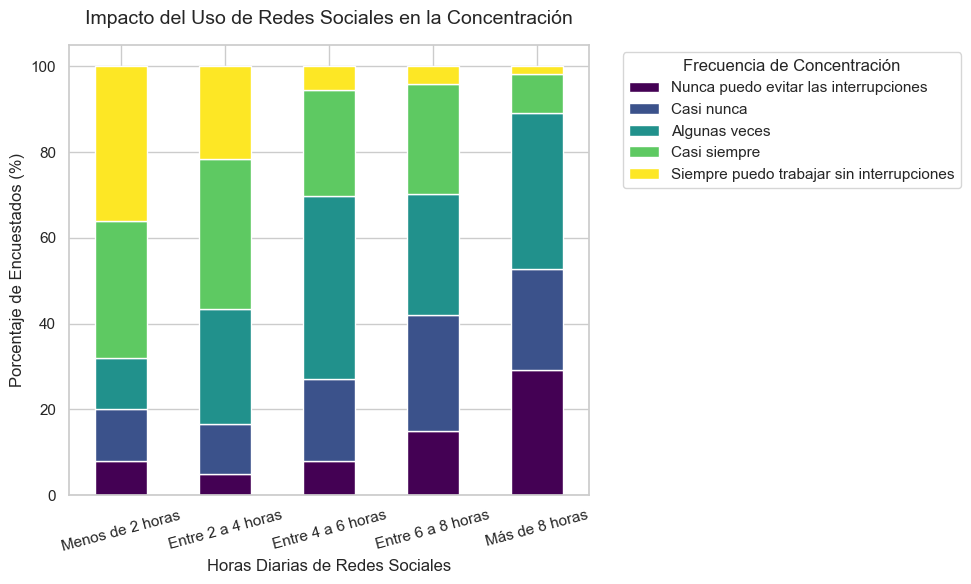

In [9]:
# Graficar la tabla porcentual con orden consistente y cierre explícito de la figura
fig, ax = plt.subplots(figsize=(10, 6))
tabla_porcentual.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")

ax.set_title("Impacto del Uso de Redes Sociales en la Concentración", fontsize=14, pad=15)
ax.set_xlabel("Horas Diarias de Redes Sociales", fontsize=12)
ax.set_ylabel("Porcentaje de Encuestados (%)", fontsize=12)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Frecuencia de Concentración", bbox_to_anchor=(1.05, 1), loc="upper left")

fig.tight_layout()
fig.savefig("grafico_concentracion.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)